In [ ]:
#Import all required libraries
import os
import sys
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool, GlobalAttention
from torch_cluster import radius_graph

from pymatgen.core import Structure
from pymatgen.io.cif import CifParser
from pymatgen.core.periodic_table import Element
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN # Fixed import path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
torch.manual_seed(42)
np.random.seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/IML Project"
DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
GRAPH_DIR = BASE_DIR

os.makedirs(GRAPH_DIR, exist_ok=True)


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive


NameError: name 'os' is not defined

In [ ]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Remove duplicates (important for materials datasets)
df = df.drop_duplicates(subset=['mp_material_id']).reset_index(drop=True)

# Drop rows with missing CIF or label
df = df.dropna(subset=['cif', 'label'])

print("Dataset size after cleaning:", len(df))
print(df['label'].value_counts())

Dataset size after cleaning: 9668
label
0    5198
1    4470
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(df['label'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([0.9300, 1.0814], device='cuda:0')


In [ ]:
exclude_cols = [
    'mp_material_id', 'mp_formula',
    'Topological Label', 'label', 'cif'
]

tabular_cols = [col for col in df.columns if col not in exclude_cols]

print("Tabular features:", tabular_cols)

Tabular features: ['spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity']


In [ ]:
if 'spacegroup' in tabular_cols:
    tabular_cols.remove('spacegroup')

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 6767
Val: 1450
Test: 1451


In [ ]:
def get_atom_features(site):
    el = Element(site.specie.symbol)

    def safe(val):
        return float(val) if val is not None else 0.0

    return np.array([
        safe(el.Z),
        safe(el.X),
        safe(el.atomic_radius),
        safe(el.group),
        safe(el.row),
        safe(el.mendeleev_no),
        safe(el.atomic_mass),
        float(site.coords[0])
    ], dtype=float)

In [ ]:
'''from pymatgen.core import Element

def get_atom_features(site):
    el = Element(site.specie.symbol)

    features = [
        el.Z,                              # Atomic number
        el.X if el.X else 0,               # Electronegativity
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0,
        el.mendeleev_no if el.mendeleev_no else 0,
        el.atomic_mass,
        site.coords[0]  # simple positional signal (x-coordinate)
    ]

    return np.array(features, dtype=float)'''

In [ ]:
def gaussian_rbf(distances, D_min=0, D_max=6, D_count=50):
    D_mu = np.linspace(D_min, D_max, D_count)
    D_sigma = (D_max - D_min) / D_count
    return np.exp(-((distances[:, None] - D_mu)**2) / (2 * D_sigma**2))

In [ ]:
'''def gaussian_rbf(distances, D_min=0, D_max=6, D_count=50):
    D_mu = np.linspace(D_min, D_max, D_count)
    D_sigma = (D_max - D_min) / D_count
    return np.exp(-((distances[:, None] - D_mu)**2) / (2 * D_sigma**2))'''

In [ ]:

def build_graph(row):
    cif_path = os.path.join(GRAPH_DIR, row['cif'])

    if not os.path.exists(cif_path):
        return None

    try:
        structure = CifParser(cif_path).parse_structures(primitive=False)[0]
    except:
        return None

    try:
        node_features = []
        positions = []

        for site in structure:
            node_features.append(get_atom_features(site))
            positions.append(site.coords)

        if len(node_features) == 0:
            return None

        x = torch.tensor(node_features, dtype=torch.float)
        pos = torch.tensor(positions, dtype=torch.float)

        edge_index = radius_graph(pos, r=6.0, loop=False, max_num_neighbors=50)

        if edge_index.size(1) == 0:
            return None

        row_idx, col_idx = edge_index
        distances = torch.norm(pos[row_idx] - pos[col_idx], dim=1).numpy()

        edge_attr = torch.tensor(gaussian_rbf(distances), dtype=torch.float)

        # GLOBAL FEATURES
        global_values = pd.to_numeric(row[tabular_cols], errors='coerce').values
        global_values = np.nan_to_num(global_values, nan=0.0)

        global_feat = torch.tensor(global_values, dtype=torch.float)

        y = torch.tensor([row['label']], dtype=torch.float)

        return Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y,
            global_feat=global_feat
        )

    except:
        return None

In [ ]:
from torch_geometric.data import Data

def build_graph(row):
    cif_path = os.path.join(GRAPH_DIR, row['cif'])

    try:
        structure = CifParser(cif_path).get_structures()[0]
    except:
        return None

    # Node features
    node_features = []
    positions = []

    for site in structure:
        node_features.append(get_atom_features(site))
        positions.append(site.coords)

    node_features = torch.tensor(node_features, dtype=torch.float)
    positions = torch.tensor(positions, dtype=torch.float)

    # Build edges (radius graph)
    edge_index = radius_graph(
        positions, r=6.0, loop=False, max_num_neighbors=50
    )

    # Edge distances
    row_idx, col_idx = edge_index
    distances = torch.norm(positions[row_idx] - positions[col_idx], dim=1).numpy()

    # Gaussian expansion
    edge_attr = torch.tensor(gaussian_rbf(distances), dtype=torch.float)

    # Global/tabular features
    global_features = torch.tensor(row[tabular_cols].values, dtype=torch.float)

    # Label
    y = torch.tensor([row['label']], dtype=torch.float)

    return Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        global_feat=global_features
    )

In [ ]:
def build_dataset(dataframe):
    data_list = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        graph = build_graph(row)
        if graph is not None:
            data_list.append(graph)

    return data_list

In [ ]:
'''def build_graph(row):
    cif_path = os.path.join(GRAPH_DIR, row['cif'])

    #Check path
    if not os.path.exists(cif_path):
        print("Missing file:", cif_path)
        return None

    try:
        parser = CifParser(cif_path)
        structures = parser.parse_structures(primitive=False)

        if len(structures) == 0:
            print("Empty structure:", cif_path)
            return None

        structure = structures[0]

    except Exception as e:
        print("Parse error:", cif_path)
        print("Error:", str(e)[:200])
        return None

    try:
        # Nodes
        node_features = []
        positions = []

        for site in structure:
            node_features.append(get_atom_features(site))
            positions.append(site.coords)

        if len(node_features) == 0:
            print("No atoms:", cif_path)
            return None

        x = torch.tensor(node_features, dtype=torch.float)
        pos = torch.tensor(positions, dtype=torch.float)

        # Edges
        edge_index = radius_graph(pos, r=6.0, loop=False, max_num_neighbors=50)

        if edge_index.size(1) == 0:
            print("No edges:", cif_path)
            return None

        row_idx, col_idx = edge_index
        distances = torch.norm(pos[row_idx] - pos[col_idx], dim=1).numpy()

        edge_attr = torch.tensor(gaussian_rbf(distances), dtype=torch.float)

        global_feat = torch.tensor(row[tabular_cols].values, dtype=torch.float)
        y = torch.tensor([row['label']], dtype=torch.float)

        return Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y,
            global_feat=global_feat
        )

    except Exception as e:
        print("Graph build error:", cif_path)
        print("Error:", str(e)[:200])
        return None'''

In [ ]:
'''for i in range(5):
    build_graph(train_df.iloc[i])'''

Missing file: /content/drive/MyDrive/IML Project/graphs/cifs/mp-1200872.cif
Missing file: /content/drive/MyDrive/IML Project/graphs/cifs/mp-24081.cif
Missing file: /content/drive/MyDrive/IML Project/graphs/cifs/mp-760.cif
Missing file: /content/drive/MyDrive/IML Project/graphs/cifs/mp-1018947.cif
Missing file: /content/drive/MyDrive/IML Project/graphs/cifs/mp-1017558.cif


In [ ]:
'''from tqdm import tqdm

def build_dataset(df):
    data_list = []
    failed = 0

    for _, row in tqdm(df.iterrows(), total=len(df)):
        graph = build_graph(row)

        if graph is None:
            failed += 1
        else:
            data_list.append(graph)

    print(f"Built: {len(data_list)} | Failed: {failed}")
    return data_list


train_data = build_dataset(train_df)
val_data   = build_dataset(val_df)
test_data  = build_dataset(test_df)

print("Train graphs:", len(train_data))
print("Val graphs:", len(val_data))
print("Test graphs:", len(test_data))'''

100%|██████████| 6767/6767 [00:02<00:00, 2401.62it/s]


Built: 0 | Failed: 6767


100%|██████████| 1450/1450 [00:00<00:00, 3199.23it/s]


Built: 0 | Failed: 1450


100%|██████████| 1451/1451 [00:00<00:00, 3166.25it/s]

Built: 0 | Failed: 1451
Train graphs: 0
Val graphs: 0
Test graphs: 0


In [ ]:
train_data = build_dataset(train_df)
val_data   = build_dataset(val_df)
test_data  = build_dataset(test_df)

print("Train graphs:", len(train_data))
print("Val graphs:", len(val_data))
print("Test graphs:", len(test_data))

  0%|          | 1/6767 [00:00<1:11:22,  1.58it/s]

Graph build error: /content/drive/MyDrive/IML Project/cifs/mp-1200872.cif
Error: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.


  0%|          | 2/6767 [00:01<1:01:38,  1.83it/s]

Graph build error: /content/drive/MyDrive/IML Project/cifs/mp-24081.cif
Error: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.


  0%|          | 3/6767 [00:01<52:58,  2.13it/s]  

...

Graph build error: /content/drive/MyDrive/IML Project/cifs/mp-2794.cif
Error: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.


  9%|▉         | 613/6767 [04:10<37:55,  2.70it/s]

Graph build error: /content/drive/MyDrive/IML Project/cifs/mp-1079270.cif
Error: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.


  9%|▉         | 613/6767 [04:10<41:59,  2.44it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(train_data, os.path.join(BASE_DIR, 'train.pt'))
torch.save(val_data,   os.path.join(BASE_DIR, 'val.pt'))
torch.save(test_data,  os.path.join(BASE_DIR, 'test.pt'))

print("Datasets saved successfully.")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool

class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim):
        super(CharlesCGCNN, self).__init__()

        hidden_dim = 128

        # Graph layers
        self.conv1 = CGConv(node_dim, dim=edge_dim)
        self.conv2 = CGConv(node_dim, dim=edge_dim)
        self.conv3 = CGConv(node_dim, dim=edge_dim)

        # Node embedding projection
        self.node_fc = nn.Linear(node_dim, hidden_dim)

        # Global feature branch
        self.global_fc = nn.Linear(global_dim, hidden_dim)

        # Fusion layers
        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch
        global_feat = data.global_feat

        # Graph convolution
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        # Pooling
        x = global_mean_pool(x, batch)
        x = F.relu(self.node_fc(x))

        # Global branch
        g = F.relu(self.global_fc(global_feat))

        # Fusion
        x = torch.cat([x, g], dim=1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        return torch.sigmoid(self.out(x)).view(-1)

In [ ]:
from torch_geometric.loader import DataLoader

train_data = torch.load(os.path.join(BASE_DIR, 'train.pt'))
val_data   = torch.load(os.path.join(BASE_DIR, 'val.pt'))
test_data  = torch.load(os.path.join(BASE_DIR, 'test.pt'))

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64)
test_loader  = DataLoader(test_data, batch_size=64)

In [ ]:
node_dim = train_data[0].x.shape[1]
edge_dim = train_data[0].edge_attr.shape[1]
global_dim = train_data[0].global_feat.shape[0]

model = CharlesCGCNN(node_dim, edge_dim, global_dim).to(device)

In [ ]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.view(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)

            preds.extend(out.cpu().numpy())
            labels.extend(data.y.view(-1).cpu().numpy())

    preds_bin = (np.array(preds) > 0.5).astype(int)

    return preds, preds_bin, labels

In [ ]:
best_val_loss = float('inf')
patience = 50
counter = 0

train_losses = []
val_losses = []

for epoch in range(300):
    train_loss = train_epoch(train_loader)

    val_preds, val_bin, val_labels = evaluate(val_loader)
    val_loss = criterion(
        torch.tensor(val_preds),
        torch.tensor(val_labels).float()
    ).item()

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(BASE_DIR, 'best_model.pt'))
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered.")
        break

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def print_metrics(name, preds, preds_bin, labels):
    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, preds_bin):.4f}")
    print(f"F1-score : {f1_score(labels, preds_bin):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, preds):.4f}")
    print(classification_report(labels, preds_bin))

In [ ]:
model.load_state_dict(torch.load(os.path.join(BASE_DIR, 'best_model.pt')))

train_preds, train_bin, train_labels = evaluate(train_loader)
val_preds, val_bin, val_labels = evaluate(val_loader)
test_preds, test_bin, test_labels = evaluate(test_loader)

print_metrics("Train", train_preds, train_bin, train_labels)
print_metrics("Validation", val_preds, val_bin, val_labels)
print_metrics("Test", test_preds, test_bin, test_labels)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, test_bin)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_labels, test_preds)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [ ]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title("Loss Curves")
plt.show()

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
)

sample = test_data[0].to(device)

explanation = explainer(
    x=sample.x,
    edge_index=sample.edge_index,
    edge_attr=sample.edge_attr
)

print("Node importance:", explanation.node_mask)
print("Edge importance:", explanation.edge_mask)

In [ ]:
!pip install pysr
from pysr import PySRRegressor

model_sr = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log"]
)

model_sr.fit(df[tabular_cols].values, df['label'].values)

print(model_sr)

In [ ]:
BASE_DIR = "/content/drive/MyDrive/IML Project"
DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")

df = pd.read_csv(DATA_PATH)

# Basic cleaning
df = df.dropna(subset=['cif', 'label'])
df['label'] = df['label'].astype(int)

print(df.shape)
df.head()

(9668, 17)


,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

print(len(train_df), len(val_df), len(test_df))

6767 1450 1451


In [ ]:
def get_node_features(structure):
    feats = []

    for site in structure:
        el = Element(site.specie.symbol)

        feats.append([
            el.Z,
            el.X or 0,
            el.atomic_radius or 0,
            el.atomic_mass or 0,
            el.group or 0,
            el.row or 0,
            int(el.is_metal),
            el.mendeleev_no or 0
        ])

    return np.array(feats)

In [ ]:
def compute_soc(structure):
    vals = [site.specie.Z**4 for site in structure]
    return np.mean(vals), np.std(vals), np.max(vals)

def compute_symmetry(structure):
    sga = SpacegroupAnalyzer(structure)
    return int(sga.is_laue())  # inversion symmetry proxy

In [ ]:
scaler = StandardScaler()
samples = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    try:
        structure = Structure.from_file(os.path.join(BASE_DIR, row['cif']))
        structure = SpacegroupAnalyzer(structure).get_conventional_standard_structure()

        feats = get_node_features(structure)
        samples.append(feats)

    except:
        continue

samples = np.vstack(samples)
scaler.fit(samples)

print("Scaler fitted")

100%|██████████| 6767/6767 [02:48<00:00, 40.18it/s]

Scaler fitted


In [ ]:
def gaussian_expansion(distances, dmin=0, dmax=6, step=0.2, width=0.5):
    centers = np.arange(dmin, dmax + step, step)
    return np.exp(-(distances[:, None] - centers[None, :])**2 / width**2)

In [ ]:
def build_graph(row):

    try:
        path = os.path.join(BASE_DIR, row['cif'])
        structure = Structure.from_file(path)
        structure = SpacegroupAnalyzer(structure).get_conventional_standard_structure()

        # Node features
        node_feats = scaler.transform(get_node_features(structure))
        x = torch.tensor(node_feats, dtype=torch.float)

        # Edges
        nn_finder = CrystalNN()

        edge_index = []
        distances = []

        for i in range(len(structure)):
            neighbors = nn_finder.get_nn_info(structure, i)
            for nbr in neighbors:
                j = nbr['site_index']
                d = structure.get_distance(i, j)

                edge_index.append([i, j])
                distances.append(d)

        # FIX: Ensure edge_index is Long tensor (integer type)
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        distances = np.array(distances)

        edge_attr = torch.tensor(
            gaussian_expansion(distances),
            dtype=torch.float
        )

        # Global features
        soc_mean, soc_std, soc_max = compute_soc(structure)
        inversion = compute_symmetry(structure)

        global_features = [
            structure.volume,
            structure.density,
            len(structure.symbol_set),
            soc_mean,
            soc_std,
            soc_max,
            inversion
        ]

        u = torch.tensor(global_features, dtype=torch.float)

        y = torch.tensor([row['label']], dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)

    except:
        return None

In [ ]:
def build_dataset(df):
    graphs = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        g = build_graph(row)
        if g is not None:
            graphs.append(g)
    return graphs

# Rebuilding the datasets with the fixed edge_index dtype
train_graphs = build_dataset(train_df)
val_graphs   = build_dataset(val_df)
test_graphs  = build_dataset(test_df)

100%|██████████| 1451/1451 [08:57<00:00,  2.70it/s]


In [ ]:
# Re-initialize DataLoaders with the corrected graph objects
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [ ]:
class CGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden=128):
        super().__init__()

        self.embedding = nn.Linear(node_dim, hidden)

        self.conv1 = CGConv(hidden, dim=edge_dim)
        self.conv2 = CGConv(hidden, dim=edge_dim)
        self.conv3 = CGConv(hidden, dim=edge_dim)

        self.fc1 = nn.Linear(hidden + global_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u

        # Initial embedding
        x = self.embedding(x)

        # Message passing layers
        x = F.softplus(self.conv1(x, edge_index, edge_attr))
        x = F.softplus(self.conv2(x, edge_index, edge_attr))
        x = F.softplus(self.conv3(x, edge_index, edge_attr))

        # Readout: Pool node features to graph level [batch_size, hidden]
        x_pooled = global_mean_pool(x, batch)

        # FIX: Correctly reshape global features 'u' to [batch_size, global_dim]
        batch_size = x_pooled.size(0)
        u = u.view(batch_size, -1)

        # Concatenate graph-level features and global features
        combined = torch.cat([x_pooled, u], dim=1)

        combined = F.relu(self.fc1(combined))
        return self.fc2(combined).view(-1)

In [ ]:
sample = train_graphs[0]

# Re-initialize model with correct dimensions
model = CGCNN(
    node_dim=sample.x.shape[1],
    edge_dim=sample.edge_attr.shape[1],
    global_dim=sample.u.shape[0]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data)

        loss = criterion(out, data.y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(loader):
    model.eval()

    preds, probs, targets = [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            prob = torch.sigmoid(out)

            preds.extend((prob > 0.5).cpu().numpy())
            probs.extend(prob.cpu().numpy())
            targets.extend(data.y.cpu().numpy())

    return accuracy_score(targets, preds), f1_score(targets, preds), roc_auc_score(targets, probs)

In [ ]:
# Re-initialize model to apply architectural fix
sample = train_graphs[0]
model = CGCNN(
    node_dim=sample.x.shape[1],
    edge_dim=sample.edge_attr.shape[1],
    global_dim=sample.u.shape[0]
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    loss = train_epoch(train_loader)
    acc, f1, roc = evaluate(val_loader)
    print(f"Epoch {epoch+1} | Loss {loss:.4f} | Val ROC {roc:.4f}")

Epoch 1 | Loss 4067.3935 | Val ROC 0.5823
Epoch 2 | Loss 4049.3243 | Val ROC 0.5978
Epoch 3 | Loss 2659.7092 | Val ROC 0.6254
Epoch 4 | Loss 2560.0241 | Val ROC 0.6624
Epoch 5 | Loss 2107.6144 | Val ROC 0.7565
Epoch 6 | Loss 2168.1475 | Val ROC 0.6809
Epoch 7 | Loss 1843.4363 | Val ROC 0.6615
Epoch 8 | Loss 1722.7653 | Val ROC 0.5727
Epoch 9 | Loss 3064.7908 | Val ROC 0.7130
Epoch 10 | Loss 1862.5524 | Val ROC 0.7435
Epoch 11 | Loss 1854.7953 | Val ROC 0.7527
Epoch 12 | Loss 1640.1328 | Val ROC 0.7428
Epoch 13 | Loss 1886.5583 | Val ROC 0.6713
Epoch 14 | Loss 1680.2462 | Val ROC 0.7565
Epoch 15 | Loss 2525.6300 | Val ROC 0.6088
Epoch 16 | Loss 2928.9383 | Val ROC 0.6383
Epoch 17 | Loss 2013.4119 | Val ROC 0.6163
Epoch 18 | Loss 2344.9278 | Val ROC 0.7883
Epoch 19 | Loss 1083.5730 | Val ROC 0.7504
Epoch 20 | Loss 1595.2844 | Val ROC 0.6653


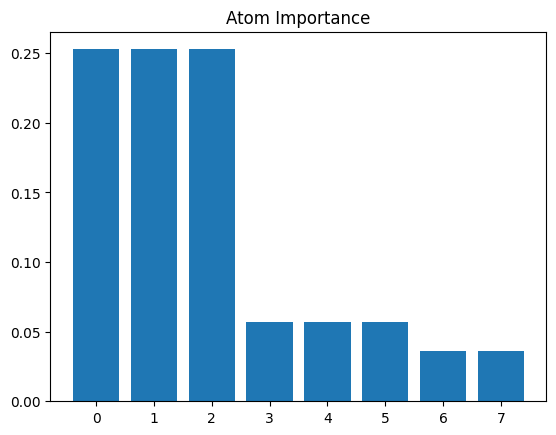

In [ ]:
data = test_graphs[0].to(device)
data.x.requires_grad = True

out = model(data)
out.backward()

importance = data.x.grad.abs().mean(dim=1).cpu().numpy()
importance /= importance.sum()

plt.bar(range(len(importance)), importance)
plt.title("Atom Importance")
plt.show()